# Matriks Ekosistem Proyek di bidang Medis & Healthcare

Deteksi tumor otak (MRI), Segmentasi sel darah, Screening COVID-19 dari X-Ray.



Dataset yang Digunakan: Dataset: BraTS, LIDC-IDRI
1. BraTS (Brain Tumor Segmentation): Dataset yang berfokus pada evaluasi metode segmentasi tumor otak (seperti glioma) menggunakan pemindaian MRI multi-parametrik.

2. LIDC-IDRI (Lung Image Database Consortium and Infectious Disease Research Institute): Dataset publik terbesar yang berisi rontgen dada (X-Ray) dan CT scan paru-paru, sering digunakan untuk deteksi nodul paru atau diagnosis penyakit pernapasan.


# Draf Kode

In [39]:
# Cell 1: Import Library yang Dibutuhkan
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Cell 2: Pengaturan Dataset (Sesuai dengan struktur folder asli)

IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # 20% untuk validasi
)

# Ganti dengan path folder utama dataset Anda 
# (folder yang berisi folder COVID, Normal, dll)
DIREKTORI_DATASET = 'Folder_Dataset' 

# Generator untuk Data Training
train_generator = train_datagen.flow_from_directory(
    DIREKTORI_DATASET, 
    classes=['COVID', 'Normal'], # Keras hanya akan membaca 2 folder ini
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',         # 'binary' karena kita hanya pakai 2 kelas
    subset='training'            # Mengambil 80% data
)

# Generator untuk Data Validasi
val_generator = train_datagen.flow_from_directory(
    DIREKTORI_DATASET,
    classes=['COVID', 'Normal'], # Harus sama dengan training
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'          # Mengambil sisa 20% data
)

Found 22094 images belonging to 2 classes.
Found 5522 images belonging to 2 classes.


In [41]:
# Cell 3: Membangun Arsitektur Model CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Sigmoid untuk klasifikasi biner
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Cell 4: Proses Training Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 406s 587ms/step - accuracy: 0.7373 - loss: 0.5808 - val_accuracy: 0.7380 - val_loss: 0.6076
Epoch 2/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 47s 68ms/step - accuracy: 0.8125 - loss: 0.4627 - val_accuracy: 0.7380 - val_loss: 0.6243
Epoch 3/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 347s 502ms/step - accuracy: 0.7382 - loss: 0.5531 - val_accuracy: 0.7382 - val_loss: 0.4983
Epoch 4/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 46s 67ms/step - accuracy: 0.6875 - loss: 0.5671 - val_accuracy: 0.7378 - val_loss: 0.4968
Epoch 5/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 287s 417ms/step - accuracy: 0.7396 - loss: 0.5289 - val_accuracy: 0.7382 - val_loss: 0.4733
Epoch 6/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - accuracy: 0.6875 - loss: 0.5421 - val_accuracy: 0.7382 - val_loss: 0.4711
Epoch 7/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 403s 584ms/step - accuracy: 0.7479 - loss: 0.5057 - val_accuracy: 0.7847 - val_loss: 0.4943
Epoch 8/10
690/690 ━━━━━━━━━━━━━━━━━━━━ 48s 70ms/step - accuracy: 0.9062 - loss: 0

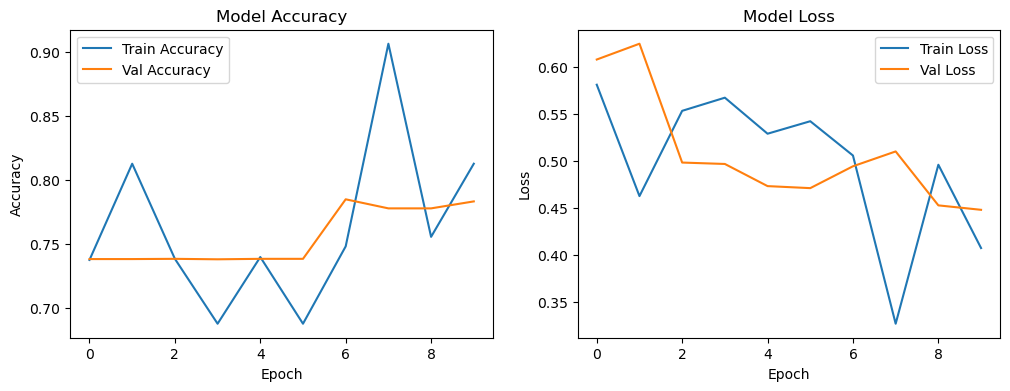

In [43]:
# Cell 5: Visualisasi Grafik Performa
plt.figure(figsize=(12, 4))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

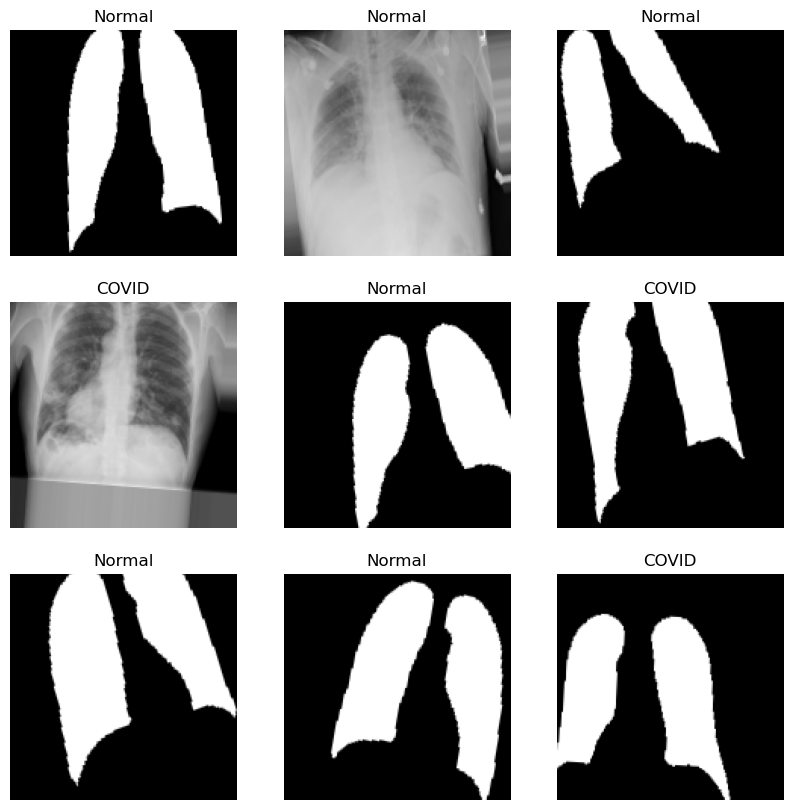

In [44]:
# Mengambil 1 kelompok (batch) data dari train_generator
gambar, label = next(train_generator)

# Mengambil nama kelas otomatis dari generator (COVID dan Normal)
nama_kelas = list(train_generator.class_indices.keys())

# Mengatur ukuran kanvas gambar
plt.figure(figsize=(10, 10))

# Menampilkan 9 gambar pertama dari batch tersebut
for i in range(9):
    plt.subplot(3, 3, i + 1)
    
    # Menampilkan gambar
    plt.imshow(gambar[i])
    
    # Menambahkan judul berdasarkan kelasnya (0 untuk COVID, 1 untuk Normal)
    indeks_kelas = int(label[i])
    plt.title(nama_kelas[indeks_kelas])
    
    # Menghilangkan garis tepi/sumbu (axis) agar lebih rapi
    plt.axis("off")

# Tampilkan hasil akhirnya
plt.show()